# Refugee Survey: Language Barriers in Refugee Services

## Data cleaning and exploratory analysis notebook

This notebook analyses the updated KoboToolbox refugee survey data in English, Kiswahili, and French.

### Objectives
- audit the raw KoboToolbox exports;
- verify consent, age eligibility, duplicate submissions, missingness, and survey duration;
- standardise multilingual responses into analysis-ready English labels;
- explore communication barriers in healthcare and legal protection services;
- examine current communication strategies and interest in digital translation tools;
- identify data-quality issues that must be considered before writing the final report.

> **Important:** The dataset contains only **seven respondents**. Results are descriptive and exploratory. Findings should be reported mainly as counts, for example **4 out of 7 respondents**, with percentages used only as supporting information. The results cannot be generalised to all refugees.


In [ ]:
from pathlib import Path
import re
import warnings
import csv
import json
from collections import Counter
from datetime import datetime, timedelta
from statistics import median

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Suppress warnings to keep notebook output readable.
warnings.filterwarnings("ignore")
# Configure pandas display options for notebook tables.
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

# Define the data folder and the two KoboToolbox exports used in this notebook.
DATA_DIR = Path("./data")
LABELS_FILE = DATA_DIR / "Refugee_Survey_Language_Barriers_in_Refugee_Services_English__Kiswahili__Français_-_all_versions_-_labels_-_2026-08-01-23-06-26.xlsx"
XML_FILE = DATA_DIR / "Refugee_Survey_Language_Barriers_in_Refugee_Services_English__Kiswahili__Français_-_all_versions_-_False_-_2026-08-01-23-06-34.xlsx"
OUTPUT_DIR = DATA_DIR / "refugee_analysis_outputs"
print("Labels file:", LABELS_FILE.name)
print("XML file:", XML_FILE.name)
print("Labels file:", LABELS_FILE.name)
print("XML file:", XML_FILE.name)

Labels file: Refugee_Survey_Language_Barriers_in_Refugee_Services_English__Kiswahili__Français_-_all_versions_-_labels_-_2026-08-01-23-06-26.xlsx
XML file: Refugee_Survey_Language_Barriers_in_Refugee_Services_English__Kiswahili__Français_-_all_versions_-_False_-_2026-08-01-23-06-34.xlsx
Labels file: Refugee_Survey_Language_Barriers_in_Refugee_Services_English__Kiswahili__Français_-_all_versions_-_labels_-_2026-08-01-23-06-26.xlsx
XML file: Refugee_Survey_Language_Barriers_in_Refugee_Services_English__Kiswahili__Français_-_all_versions_-_False_-_2026-08-01-23-06-34.xlsx


## 1. Load the KoboToolbox exports

The XML export is used for stable technical response codes.  
The labels export is retained to verify the multilingual wording and the meaning of each response option.


In [ ]:
def load_first_sheet(path):
    # Read the first sheet without headers to preserve raw Excel structure.
    df = pd.read_excel(path, sheet_name=0, header=None)
    matrix = df.values.tolist()
    used_range = None
    return df, matrix, used_range

labels_wb, labels_matrix, labels_range = load_first_sheet(LABELS_FILE)
xml_wb, xml_matrix, xml_range = load_first_sheet(XML_FILE)

labels_headers = labels_matrix[0]
xml_headers = xml_matrix[0]
labels_rows = [dict(zip(labels_headers, row)) for row in labels_matrix[1:]]
xml_rows = [dict(zip(xml_headers, row)) for row in xml_matrix[1:]]

# Report the raw sheet dimensions and row/column counts.
print("Labels used range:", labels_range)
print("XML used range:", xml_range)
print("Respondents:", len(xml_rows))
print("Columns:", len(xml_headers))

Labels used range: None
XML used range: None
Respondents: 7
Columns: 279


## 2. Helper functions

In [ ]:
def excel_datetime(value):
    # Convert Excel timestamp serials and native datetime values to Python datetime.
    if value in (None, ""):
        return None
    if isinstance(value, datetime):
        return value
    try:
        return datetime(1899, 12, 30) + timedelta(days=float(value))
    except (TypeError, ValueError):
        try:
            return pd.to_datetime(value)
        except Exception:
            return None

def yes_no(value):
    # Normalize yes/no responses to capitalized text labels.
    return {"yes": "Yes", "no": "No"}.get(value, value)

def map_value(value, mapping):
    # Map raw coded responses into readable labels, preserving unknown values.
    if value in (None, ""):
        return None
    return mapping.get(value, value.replace("_", " ").strip().title())

def frequency(values, include_missing=False):
    # Build a simple frequency summary from a list of values.
    prepared = []
    for value in values:
        if value in (None, ""):
            if include_missing:
                prepared.append("Missing")
        else:
            prepared.append(value)
    counts = Counter(prepared)
    denominator = len(prepared)
    rows = []
    for response, count in counts.most_common():
        rows.append({
            "Response": response,
            "Count": count,
            "Percent": round(count / denominator * 100, 1) if denominator else 0,
        })
    return rows

def markdown_table(rows, columns=None):
    # Display a Markdown-formatted table from a list of dictionaries.
    if not rows:
        display(Markdown("_No data available._"))
        return
    if columns is None:
        columns = list(rows[0].keys())
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = []
    for row in rows:
        body.append("| " + " | ".join(str(row.get(col, "")) for col in columns) + " |")
    display(Markdown("\n".join([header, separator] + body)))

def plot_frequency(rows, title):
    # Plot a horizontal bar chart from frequency summary rows.
    if not rows:
        return
    labels = [str(row["Response"]) for row in rows][::-1]
    counts = [row["Count"] for row in rows][::-1]
    plt.figure(figsize=(8, max(3, len(labels) * 0.55)))
    bars = plt.barh(labels, counts)
    plt.title(title)
    plt.xlabel("Number of respondents")
    for bar, value in zip(bars, counts):
        plt.text(value + 0.05, bar.get_y() + bar.get_height() / 2, str(value), va="center")
    plt.tight_layout()
    plt.show()

def multiselect_counts(rows, option_map):
    # Count selected options for matrix/select-multiple questions.
    summary = []
    denominator = len(rows)
    for technical_column, readable_label in option_map.items():
        count = sum(1 for row in rows if row.get(technical_column) == 1)
        if count:
            summary.append({
                "Response": readable_label,
                "Count": count,
                "Percent": round(count / denominator * 100, 1),
            })
    return sorted(summary, key=lambda x: (-x["Count"], x["Response"]))

def write_csv(path, rows, fieldnames=None):
    # Write rows of dictionaries to a CSV file, creating directories as needed.
    if not rows:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    if fieldnames is None:
        fieldnames = list(rows[0].keys())
    with path.open("w", newline="", encoding="utf-8-sig") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

## 3. Raw-data audit

In [ ]:
consent_key = "I_voluntarily_agree_to_partici"
adult_key = "Are_you_18_years_of_age_or_old"

quality_rows = []
for row in xml_rows:
    start = excel_datetime(row.get("start"))
    end = excel_datetime(row.get("end"))
    duration = None
    if start and end:
        duration = round((end - start).total_seconds() / 60, 1)
    quality_rows.append({
        "Respondent": row.get("_index"),
        "UUID": row.get("_uuid"),
        "Form version": row.get("__version__"),
        "Consent": yes_no(row.get(consent_key)),
        "Age 18+": yes_no(row.get(adult_key)),
        "Duration (minutes)": duration,
    })

# Summarise data quality and duplicate UUID issues across all submissions.
uuid_counts = Counter(row["UUID"] for row in quality_rows)
duplicate_uuid_count = sum(1 for row in quality_rows if uuid_counts[row["UUID"]] > 1)
durations = [row["Duration (minutes)"] for row in quality_rows if row["Duration (minutes)"] is not None]

audit = [
    {"Metric": "Total submissions", "Value": len(xml_rows)},
    {"Metric": "Eligible by consent and age", "Value": sum(1 for row in quality_rows if row["Consent"] == "Yes" and row["Age 18+"] == "Yes")},
    {"Metric": "Unique UUIDs", "Value": len(uuid_counts)},
    {"Metric": "Records with duplicate UUIDs", "Value": duplicate_uuid_count},
    {"Metric": "Form versions", "Value": len(set(row.get("__version__") for row in xml_rows))},
    {"Metric": "Median completion time (minutes)", "Value": round(median(durations), 1)},
    {"Metric": "Minimum completion time (minutes)", "Value": min(durations)},
    {"Metric": "Maximum completion time (minutes)", "Value": max(durations)},
]

markdown_table(audit)
display(Markdown("### Submission-level quality check"))
markdown_table(quality_rows)

| Metric | Value |
| --- | --- |
| Total submissions | 7 |
| Eligible by consent and age | 7 |
| Unique UUIDs | 7 |
| Records with duplicate UUIDs | 0 |
| Form versions | 1 |
| Median completion time (minutes) | 20.9 |
| Minimum completion time (minutes) | 4.3 |
| Maximum completion time (minutes) | 712.4 |

### Submission-level quality check

| Respondent | UUID | Form version | Consent | Age 18+ | Duration (minutes) |
| --- | --- | --- | --- | --- | --- |
| 1 | a3644c91-46b7-4707-a22a-e2e6f2462e82 | veEwBQ9CuKPNrVgwkZSSU6 | Yes | Yes | 712.4 |
| 2 | eb19b17e-e73f-4038-8129-096274ed6ba5 | veEwBQ9CuKPNrVgwkZSSU6 | Yes | Yes | 16.3 |
| 3 | 85ab95d1-143a-43a6-ac42-a75b78a6a7f9 | veEwBQ9CuKPNrVgwkZSSU6 | Yes | Yes | 44.3 |
| 4 | b2e6c83f-3529-45bf-be5c-bdfd9fcb818b | veEwBQ9CuKPNrVgwkZSSU6 | Yes | Yes | 20.9 |
| 5 | d36c3ea6-2fa4-4877-9529-7e06428c6abc | veEwBQ9CuKPNrVgwkZSSU6 | Yes | Yes | 4.3 |
| 6 | f93958e1-e017-44f2-bb04-e3c29cc4afa7 | veEwBQ9CuKPNrVgwkZSSU6 | Yes | Yes | 20.3 |
| 7 | 9532c5f1-f686-4988-b375-2963b703cf88 | veEwBQ9CuKPNrVgwkZSSU6 | Yes | Yes | 23.7 |

### Initial quality observations

- All seven respondents consented and reported being at least 18 years old.
- All UUIDs are unique.
- One submission took approximately 712 minutes, which probably indicates that the form was left open or completed in more than one sitting. It should not be treated as an exclusion criterion by itself.
- The questions on **formal refugee status** and whether the respondent had previously sought healthcare or legal services are blank for all seven submissions. These eligibility characteristics therefore cannot be verified from the direct screening fields.


## 4. Construct the cleaned respondent-level dataset

In [ ]:
settlement_map = {
    "uganda__bidibidi": "Uganda, Bidibidi",
    "kenya__kakuma": "Kenya, Kakuma",
    "other_settlement_kenya": "Other refugee-hosting area in Kenya",
}
age_map = {
    "18_24_years": "18-24 years",
    "25_34_years": "25-34 years",
}
gender_map = {"male": "Male", "female": "Female"}
country_map = {
    "drc": "Democratic Republic of the Congo",
    "other__nyingine__autre": "Other",
}
duration_map = {
    "less_than_1_year": "Less than 1 year",
    "4_6_years": "4-6 years",
    "7_years_or_more": "7 years or more",
}
education_map = {
    "secondary_education": "Secondary education",
    "vocational_technical_education": "Vocational/technical education",
}
ability_map = {
    "fair": "Fair",
    "good": "Good",
    "very_good": "Very good",
}
frequency_map = {
    "never": "Never",
    "rarely": "Rarely",
    "sometimes": "Sometimes",
    "often": "Often",
    "always": "Always",
}
phone_map = {
    "smartphone__with_internet_access": "Smartphone with internet access",
}
internet_map = {
    "daily": "Daily",
    "a_few_times_a_week": "A few times a week",
}
reading_map = {"very_comfortable": "Very comfortable"}
ease_map = {
    "very_easy": "Very easy",
    "easy": "Easy",
    "neither_easy_nor_difficult": "Neither easy nor difficult",
}
language_map = {
    "swahili": "Swahili",
    "english": "English",
    "french": "French",
}
satisfaction_map = {
    "satisfied": "Satisfied",
    "very_satisfied": "Very satisfied",
    "3___neutral": "Neutral",
    "4___satisfied": "Satisfied",
    "5___very_satisfied": "Very satisfied",
    "2___dissatisfied": "Dissatisfied",
}
support_map = {
    "1___very_poor": "Very poor",
    "3___fair___average": "Fair/Average",
    "4___good": "Good",
    "5___excellent": "Excellent",
}

cleaned = []
for row in xml_rows:
    start = excel_datetime(row.get("start"))
    end = excel_datetime(row.get("end"))
    duration = round((end - start).total_seconds() / 60, 1) if start and end else None

    country = map_value(row.get("What_is_your_country_of_origin"), country_map)
    if country == "Other":
        country_detail = row.get("Please_specify_Taf_Veuillez_pr_ciser_001")
        if country_detail:
            country = str(country_detail).strip().title()

    # Build a consolidated respondent record with mapped labels.
    record = {
        "respondent_id": row.get("_index"),
        "uuid": row.get("_uuid"),
        "form_version": row.get("__version__"),
        "consent": yes_no(row.get(consent_key)),
        "adult_18_plus": yes_no(row.get(adult_key)),
        "duration_minutes": duration,
        "settlement": map_value(row.get("In_which_refugee_settlement_or"), settlement_map),
        "formal_status": row.get("What_is_your_formal_status_in_"),
        "previously_sought_services": row.get("Have_you_ever_sought_primary_h"),
        "age_group": map_value(row.get("What_is_your_age_Un_Quel_est_votre_ge_"), age_map),
        "gender": map_value(row.get("What_is_your_Gender_Quel_est_votre_sexe_"), gender_map),
        "country_of_origin": country,
        "time_in_settlement": map_value(row.get("How_long_have_you_li_de_r_fugi_s_actuel_"), duration_map),
        "education": map_value(row.get("What_is_the_highest_e_vous_avez_termin_"), education_map),
        "primary_language_raw": row.get("Please_specify_Taf_Veuillez_pr_ciser_002"),
        "english_speaking_ability": map_value(row.get("How_would_you_rate_y_t_parler_anglais__001"), ability_map),
        "english_understanding_ability": map_value(row.get("How_would_you_rate_y_omprendre_l_anglais__001"), ability_map),
        "interpreter_need": map_value(row.get("How_often_do_you_nee_rotection_juridique__001"), frequency_map),
        "usual_service_language": map_value(row.get("Which_language_do_you_usually_"), language_map),
        "phone_access": map_value(row.get("What_type_of_phone_d_actuellement_acc_s_"), phone_map),
        "internet_access": map_value(row.get("How_often_do_you_hav_mobile_ou_au_Wi_Fi_"), internet_map),
        "reading_comfort": map_value(row.get("How_comfortable_are_porte_quelle_langue_"), reading_map),
        "communication_ease": map_value(row.get("Overall_how_easy_is_ataires_de_services_"), ease_map),
        "experienced_communication_difficulty": yes_no(row.get("Have_you_ever_experi_rotection_juridique_")),
        "language_barrier_frequency": map_value(
            row.get("How_often_do_languag_ataires_de_services__001"),
            {
                "1___never": "Never",
                "2___rarely": "Rarely",
                "3___sometimes": "Sometimes",
                "4___very_often": "Very often",
            },
        ),
        "usual_response_to_difficulty": map_value(
            row.get("When_you_experience_communicat"),
            {
                "ask_a_family_member_or_friend_to_interpr": "Ask a family member or friend to interpret",
                "ask_another_refugee_for_help": "Ask another refugee for help",
                "use_gestures_or_body_language": "Use gestures or body language",
                "other": "Other",
            },
        ),
        "communication_satisfaction": map_value(row.get("Overall_how_satisfi_rotection_juridique_"), satisfaction_map),
        "left_without_help": yes_no(row.get("Have_you_ever_left_a_rri_re_linguistique_")),
        "sensitive_information_comfort": map_value(
            row.get("When_an_interpreter_nelles_ou_sensibles_"),
            {
                "very_comfortable": "Very comfortable",
                "comfortable": "Comfortable",
                "neutral": "Neutral",
                "uncomfortable": "Uncomfortable",
            },
        ),
        "healthcare_access_frequency": map_value(
            row.get("How_often_do_you_acc_nt_dans_votre_site_"),
            {
                "frequently__once_a_month_or_more": "Frequently (once a month or more)",
                "occasionally__several_times_a_year": "Occasionally (several times a year)",
                "rarely__once_a_year_or_less": "Rarely (once a year or less)",
            },
        ),
        "healthcare_barrier": yes_no(row.get("Have_language_barrie_x_services_de_sant_")),
        "delayed_healthcare": yes_no(row.get("Have_you_ever_avoide_rri_re_linguistique_")),
        "health_interpreter_availability": map_value(
            row.get("During_your_healthca_le_en_cas_de_besoin__001"),
            {
                "1___never": "Never",
                "2___rarely": "Rarely",
                "3___sometimes": "Sometimes",
                "4___often": "Often",
                "5___always": "Always",
            },
        ),
        "health_communication_satisfaction": map_value(row.get("Overall_how_satisfi_s_visites_m_dicales_"), satisfaction_map),
        "health_put_at_risk": yes_no(row.get("Do_you_feel_a_langua_diagnostic_manqu_")),
        "legal_barrier": yes_no(row.get("Have_language_barrie_ou_d_aide_juridique_")),
        "legal_interpreter_availability": map_value(
            row.get("Was_an_interpWas_an_protection_services"),
            {
                "1___never": "Never",
                "3___sometimes": "Sometimes",
                "4___often": "Often",
                "5___always": "Always",
            },
        ),
        "legal_sensitive_comfort": map_value(
            row.get("I_feel_comfortable_r_lisant_un_interpr_te"),
            {"strongly_agree": "Strongly agree", "agree": "Agree", "neutral": "Neutral"},
        ),
        "legal_communication_satisfaction": map_value(row.get("Overall_how_satisfi_ou_d_aide_juridique_"), satisfaction_map),
        "used_translation_app": map_value(
            row.get("Have_you_ever_used_a_tataire_de_services_"),
            {
                "yes__and_it_worked_well": "Yes, and it worked well",
                "no__never_tried": "No, never tried",
            },
        ),
        "likelihood_use_free_tool": map_value(
            row.get("If_a_free_phone_base_ilit_de_l_utiliser_"),
            {
                "3___neutral": "Neutral",
                "4___somewhat_likely": "Somewhat likely",
                "5___very_likely": "Very likely",
            },
        ),
        "machine_translation_trust": map_value(
            row.get("How_much_do_you_trus_uridiques_sensibles__001"),
            {"3___moderately": "Moderately", "4___mostly": "Mostly"},
        ),
        "preferred_tool_format": map_value(
            row.get("Which_format_would_b_s_facile_utiliser_"),
            {
                "a_voice_call_i_can_speak_into__no_readin": "Voice call with no reading required",
                "a_smartphone_app": "Smartphone app",
                "i_would_prefer_a_human_interpreter_over_": "Human interpreter rather than technology",
            },
        ),
        "preferred_interpretation_support": map_value(
            row.get("Who_would_you_prefer_cales_ou_juridiques_"),
            {
                "professional_interpreter": "Professional interpreter",
                "bilingual_staff_member": "Bilingual staff member",
                "digital_translation_tool": "Digital translation tool",
                "no_preference": "No preference",
            },
        ),
        "main_interpretation_concern": map_value(
            row.get("What_is_your_biggest_concern_w"),
            {
                "they_may_translate_incorrectly": "Incorrect translation",
                "they_may_share_my_private_information": "Disclosure of private information",
                "i_may_feel_embarrassed": "Embarrassment",
            },
        ),
        "comfortable_voice_recording": map_value(
            row.get("Would_you_feel_comfo_cales_ou_juridiques_"),
            {"yes": "Yes", "no": "No", "not_sure": "Not sure"},
        ),
        "overall_language_support": map_value(row.get("How_would_you_rate_t_personnel_bilingue__001"), support_map),
    }
    cleaned.append(record)

print("Cleaned records:", len(cleaned))
markdown_table(cleaned[:3], columns=[
    "respondent_id", "settlement", "age_group", "gender", "country_of_origin",
    "primary_language_raw", "interpreter_need", "experienced_communication_difficulty"
])

Cleaned records: 7


| respondent_id | settlement | age_group | gender | country_of_origin | primary_language_raw | interpreter_need | experienced_communication_difficulty |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | Uganda, Bidibidi | 18-24 years | Male | Democratic Republic of the Congo | Kiswahili | Often | No |
| 2 | Kenya, Kakuma | 25-34 years | Male | Democratic Republic of the Congo | Lingala and kiswahili | Never | No |
| 3 | Kenya, Kakuma | 18-24 years | Male | Democratic Republic of the Congo | KISWAHILI NA KINGEREZA | Always | Yes |

## 5. Completeness and logical consistency checks

In [ ]:
core_fields = [
    "settlement", "formal_status", "previously_sought_services", "age_group", "gender",
    "country_of_origin", "primary_language_raw", "interpreter_need",
    "experienced_communication_difficulty", "healthcare_barrier", "legal_barrier",
    "preferred_tool_format", "overall_language_support",
    ]

completeness_rows = []
for field in core_fields:
    valid = sum(1 for row in cleaned if row.get(field) not in (None, ""))
    completeness_rows.append({
        "Variable": field,
        "Valid responses": valid,
        "Missing": len(cleaned) - valid,
        "Completion rate": f"{round(valid / len(cleaned) * 100, 1)}%",
    })

# Display completion rates for key fields in the cleaned respondent dataset.
markdown_table(completeness_rows)

# Contradiction checks help identify inconsistent responses across related questions.
communication_challenge_map = {
    "Which_communication_challenges/i_could_not_understand_the_language_spok": "Could not understand provider language",
    "Which_communication_challenges/the_service_provider_could_not_understan": "Provider could not understand respondent language",
    "Which_communication_challenges/there_was_no_interpreter_available": "No interpreter available",
    "Which_communication_challenges/information_was_not_translated_into_my_l": "Information not translated",
    "Which_communication_challenges/i_was_afraid_or_embarrassed_to_ask_quest": "Afraid or embarrassed to ask questions",
    "Which_communication_challenges/other": "Other",
}

contradictions = []

for row in xml_rows:
    selected_general = [
        label for key, label in communication_challenge_map.items() if row.get(key) == 1
    ]
    if row.get("Have_you_ever_experi_rotection_juridique_") == "no" and selected_general:
        contradictions.append({
            "Respondent": row.get("_index"),
            "Check": "Reported no communication difficulty but selected at least one challenge",
            "Details": "; ".join(selected_general),
        })

    if (
        row.get("What_type_of_phone_d_actuellement_acc_s_") == "smartphone__with_internet_access"
        and row.get("What_stops_you_from_on_pour_communiquer_/i_don_t_own_a_phone") == 1
    ):
        contradictions.append({
            "Respondent": row.get("_index"),
            "Check": "Reported smartphone access but also selected 'I do not own a phone'",
            "Details": "Phone access response conflicts with digital-barrier response",
        })

    legal_specific = any(
        row.get(key) == 1
        for key in [
            "Which_communication_challenges_001/difficulty_explaining_my_legal_concerns",
            "Which_communication_challenges_001/difficulty_understanding_legal_advice",
            "Which_communication_challenges_001/difficulty_understanding_legal_procedure",
            "Which_communication_challenges_001/interpreter_not_available",
            "Which_communication_challenges_001/fear_of_misunderstanding_important_infor",
        ]
    )
    if (
        row.get("Which_communication_challenges_001/i_did_not_experience_any_challenges") == 1
        and legal_specific,
    ):
        contradictions.append({
            "Respondent": row.get("_index"),
            "Check": "Selected 'no legal challenges' together with a specific legal challenge",
            "Details": "Mutually inconsistent multiple-choice selections",
        })

display(Markdown("### Records requiring cautious interpretation"))
markdown_table(contradictions)

| Variable | Valid responses | Missing | Completion rate |
| --- | --- | --- | --- |
| settlement | 7 | 0 | 100.0% |
| formal_status | 7 | 0 | 100.0% |
| previously_sought_services | 7 | 0 | 100.0% |
| age_group | 7 | 0 | 100.0% |
| gender | 7 | 0 | 100.0% |
| country_of_origin | 7 | 0 | 100.0% |
| primary_language_raw | 7 | 0 | 100.0% |
| interpreter_need | 7 | 0 | 100.0% |
| experienced_communication_difficulty | 7 | 0 | 100.0% |
| healthcare_barrier | 7 | 0 | 100.0% |
| legal_barrier | 7 | 0 | 100.0% |
| preferred_tool_format | 7 | 0 | 100.0% |
| overall_language_support | 7 | 0 | 100.0% |

### Records requiring cautious interpretation

| Respondent | Check | Details |
| --- | --- | --- |
| 1 | Reported no communication difficulty but selected at least one challenge | Could not understand provider language |
| 1 | Selected 'no legal challenges' together with a specific legal challenge | Mutually inconsistent multiple-choice selections |
| 2 | Reported no communication difficulty but selected at least one challenge | Could not understand provider language |
| 2 | Selected 'no legal challenges' together with a specific legal challenge | Mutually inconsistent multiple-choice selections |
| 4 | Reported smartphone access but also selected 'I do not own a phone' | Phone access response conflicts with digital-barrier response |
| 5 | Reported smartphone access but also selected 'I do not own a phone' | Phone access response conflicts with digital-barrier response |
| 6 | Reported no communication difficulty but selected at least one challenge | Other |

### Data-quality interpretation

The contradictions are retained rather than silently corrected. They show where questionnaire logic or respondent interpretation may have affected the data. The final report should rely more strongly on internally consistent questions and explicitly mention these limitations.


## 6. Respondent profile

### Settlement

| Response | Count | Percent |
| --- | --- | --- |
| Kenya, Kakuma | 4 | 57.1 |
| Other refugee-hosting area in Kenya | 2 | 28.6 |
| Uganda, Bidibidi | 1 | 14.3 |

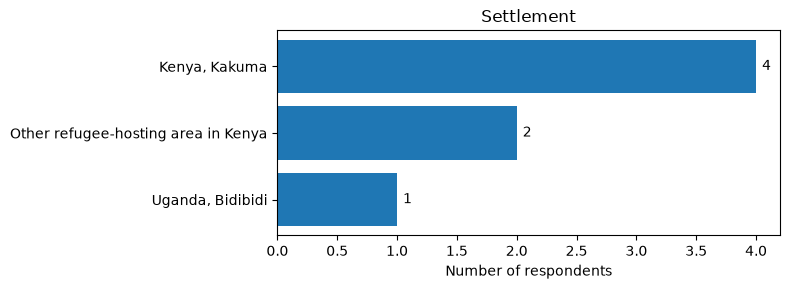

### Age group

| Response | Count | Percent |
| --- | --- | --- |
| 18-24 years | 5 | 71.4 |
| 25-34 years | 2 | 28.6 |

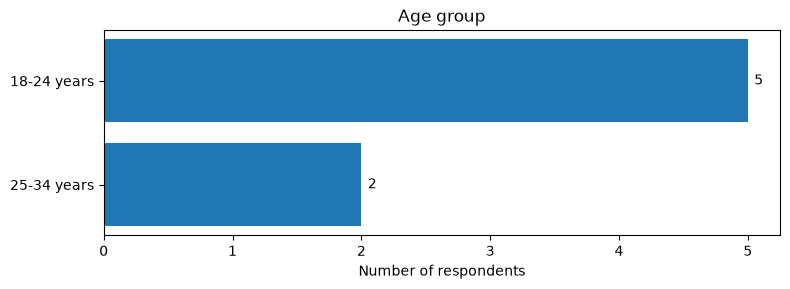

### Gender

| Response | Count | Percent |
| --- | --- | --- |
| Male | 6 | 85.7 |
| Female | 1 | 14.3 |

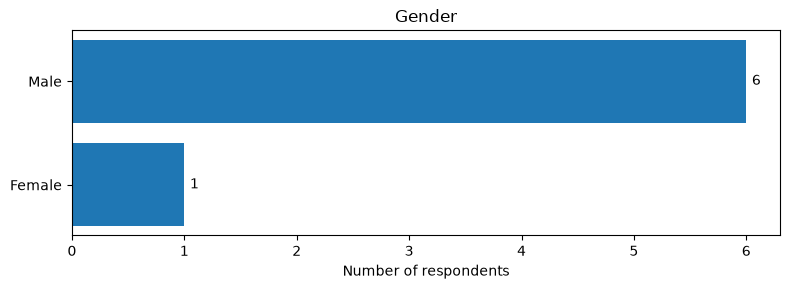

### Country of origin

| Response | Count | Percent |
| --- | --- | --- |
| Democratic Republic of the Congo | 6 | 85.7 |
| Burundi | 1 | 14.3 |

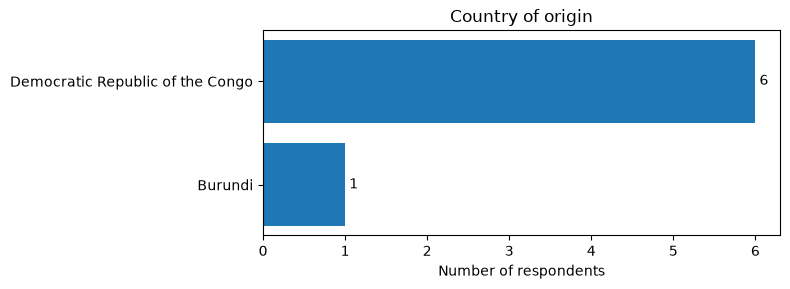

### Time in settlement

| Response | Count | Percent |
| --- | --- | --- |
| 4-6 years | 3 | 42.9 |
| 7 years or more | 3 | 42.9 |
| Less than 1 year | 1 | 14.3 |

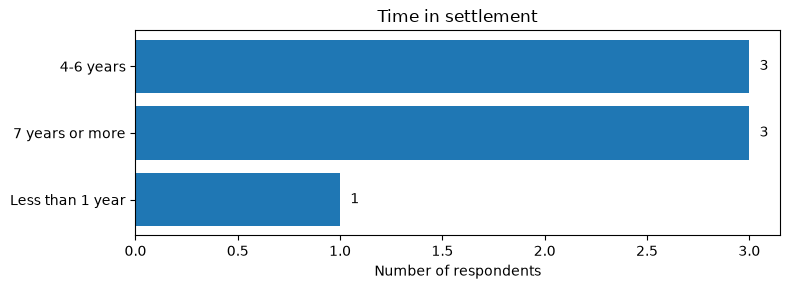

### Education

| Response | Count | Percent |
| --- | --- | --- |
| Secondary education | 5 | 71.4 |
| Vocational/technical education | 2 | 28.6 |

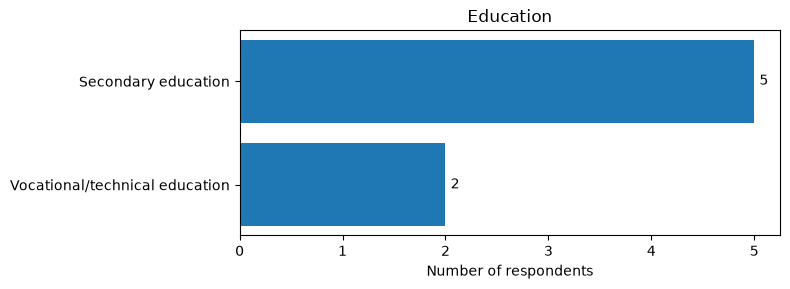

In [ ]:
profile_variables = [
    ("Settlement", "settlement"),
    ("Age group", "age_group"),
    ("Gender", "gender"),
    ("Country of origin", "country_of_origin"),
    ("Time in settlement", "time_in_settlement"),
    ("Education", "education"),
]

# Show respondent profile distributions for key demographic variables.
for title, field in profile_variables:
    display(Markdown(f"### {title}"))
    rows = frequency([record[field] for record in cleaned])
    markdown_table(rows)
    plot_frequency(rows, title)

### Primary languages

Every respondent selected **Other** for the predefined mother-tongue options and then entered a free-text language. The raw entries are preserved because they include multilingual or community-specific descriptions.


| Response | Count | Percent |
| --- | --- | --- |
| Bembe language | 2 | 28.6 |
| Kiswahili | 1 | 14.3 |
| Lingala and kiswahili | 1 | 14.3 |
| KISWAHILI NA KINGEREZA | 1 | 14.3 |
| Kinande, a language of Nande tribe in congo | 1 | 14.3 |
| kirundi | 1 | 14.3 |

### Other languages spoken

| Response | Count | Percent |
| --- | --- | --- |
| English | 5 | 71.4 |
| French | 4 | 57.1 |
| Swahili | 3 | 42.9 |
| Kinyarwanda | 1 | 14.3 |

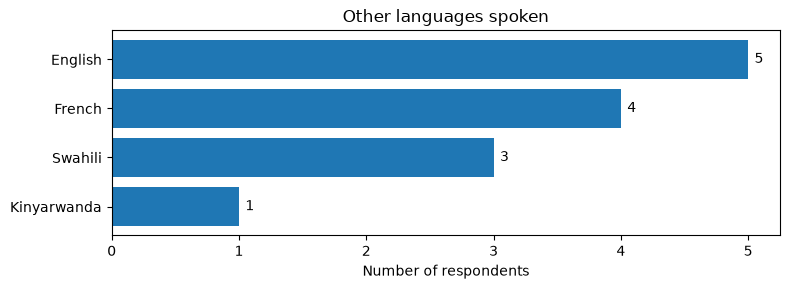

In [ ]:
# Summarise free-text primary language entries preserved from the raw export.
primary_language_rows = frequency([record["primary_language_raw"] for record in cleaned])
markdown_table(primary_language_rows)

other_language_map = {
    "Besides_your_primary_langues_parlez_vous_/english": "English",
    "Besides_your_primary_langues_parlez_vous_/swahili": "Swahili",
    "Besides_your_primary_langues_parlez_vous_/arabic": "Arabic",
    "Besides_your_primary_langues_parlez_vous_/french": "French",
    "Besides_your_primary_langues_parlez_vous_/kinyarwanda": "Kinyarwanda",
    "Besides_your_primary_langues_parlez_vous_/somali": "Somali",
    "Besides_your_primary_langues_parlez_vous_/other": "Other",
    "Besides_your_primary_langues_parlez_vous_/none": "None",
}
other_language_summary = multiselect_counts(xml_rows, other_language_map)
display(Markdown("### Other languages spoken"))
markdown_table(other_language_summary)
plot_frequency(other_language_summary, "Other languages spoken")

## 7. General communication experiences

In [ ]:
general_variables = [
    ("English-speaking ability", "english_speaking_ability"),
    ("English-understanding ability", "english_understanding_ability"),
    ("Need for an interpreter", "interpreter_need"),
    ("Language usually used with service providers", "usual_service_language"),
    ("Ease of communication with service providers", "communication_ease"),
    ("Experienced communication difficulty", "experienced_communication_difficulty"),
    ("Frequency with which language barriers affect communication", "language_barrier_frequency"),
    ("Overall communication satisfaction", "communication_satisfaction"),
    ("Left without receiving help because of a language barrier", "left_without_help"),
    ("Comfort sharing sensitive information through an interpreter", "sensitive_information_comfort"),
]

# Display frequency summaries for general refugee communication survey responses.
for title, field in general_variables:
    display(Markdown(f"### {title}"))
    rows = frequency([record[field] for record in cleaned])
    markdown_table(rows)

### English-speaking ability

| Response | Count | Percent |
| --- | --- | --- |
| Good | 4 | 57.1 |
| Fair | 2 | 28.6 |
| Very good | 1 | 14.3 |

### English-understanding ability

| Response | Count | Percent |
| --- | --- | --- |
| Good | 4 | 57.1 |
| Very good | 2 | 28.6 |
| Fair | 1 | 14.3 |

### Need for an interpreter

...

| Response | Count | Percent |
| --- | --- | --- |
| Satisfied | 6 | 85.7 |
| Very satisfied | 1 | 14.3 |

### Left without receiving help because of a language barrier

| Response | Count | Percent |
| --- | --- | --- |
| No | 5 | 71.4 |
| Yes | 2 | 28.6 |

### Comfort sharing sensitive information through an interpreter

| Response | Count | Percent |
| --- | --- | --- |
| Comfortable | 3 | 42.9 |
| Very comfortable | 2 | 28.6 |
| Uncomfortable | 1 | 14.3 |
| Neutral | 1 | 14.3 |

### Communication challenges selected

| Response | Count | Percent |
| --- | --- | --- |
| Could not understand provider language | 5 | 71.4 |
| Afraid or embarrassed to ask questions | 1 | 14.3 |
| No interpreter available | 1 | 14.3 |
| Other | 1 | 14.3 |
| Provider could not understand respondent language | 1 | 14.3 |

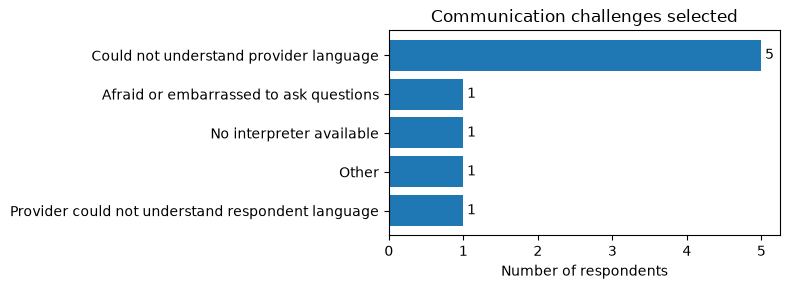

### Usual response to communication difficulty

| Response | Count | Percent |
| --- | --- | --- |
| Ask a family member or friend to interpret | 3 | 42.9 |
| Ask another refugee for help | 2 | 28.6 |
| Other | 1 | 14.3 |
| Use gestures or body language | 1 | 14.3 |

In [ ]:
general_challenge_summary = multiselect_counts(xml_rows, communication_challenge_map)
display(Markdown("### Communication challenges selected"))
markdown_table(general_challenge_summary)
plot_frequency(general_challenge_summary, "Communication challenges selected")

response_to_difficulty_rows = frequency([record["usual_response_to_difficulty"] for record in cleaned])
display(Markdown("### Usual response to communication difficulty"))
markdown_table(response_to_difficulty_rows)

## 8. Healthcare access and communication

### Frequency of healthcare use

| Response | Count | Percent |
| --- | --- | --- |
| Occasionally (several times a year) | 3 | 42.9 |
| Rarely (once a year or less) | 3 | 42.9 |
| Frequently (once a month or more) | 1 | 14.3 |

### Language barriers made healthcare access challenging

| Response | Count | Percent |
| --- | --- | --- |
| No | 4 | 57.1 |
| Yes | 3 | 42.9 |

### Avoided or delayed healthcare because of an expected language barrier

...

| Response | Count | Percent |
| --- | --- | --- |
| Satisfied | 4 | 57.1 |
| Neutral | 2 | 28.6 |
| Very satisfied | 1 | 14.3 |

### Language barrier perceived to have put health at risk

| Response | Count | Percent |
| --- | --- | --- |
| Yes | 4 | 57.1 |
| No | 3 | 42.9 |

### Healthcare communication challenges

| Response | Count | Percent |
| --- | --- | --- |
| Did not experience any challenges | 4 | 57.1 |
| Difficulty explaining symptoms | 2 | 28.6 |
| Difficulty understanding the healthcare provider | 1 | 14.3 |

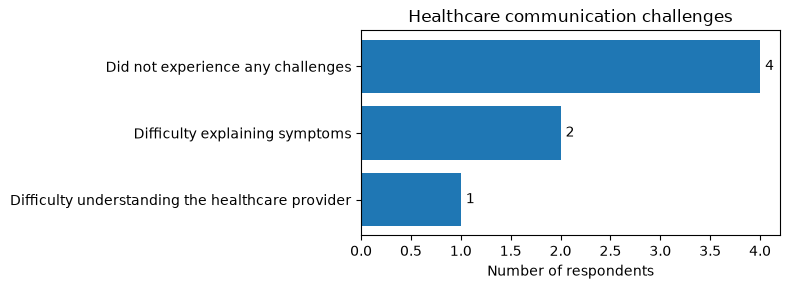

In [ ]:
health_variables = [
    ("Frequency of healthcare use", "healthcare_access_frequency"),
    ("Language barriers made healthcare access challenging", "healthcare_barrier"),
    ("Avoided or delayed healthcare because of an expected language barrier", "delayed_healthcare"),
    ("Interpreter availability during healthcare visits", "health_interpreter_availability"),
    ("Communication satisfaction during healthcare visits", "health_communication_satisfaction"),
    ("Language barrier perceived to have put health at risk", "health_put_at_risk"),
]

# Display healthcare-related response patterns and challenge selections.
for title, field in health_variables:
    display(Markdown(f"### {title}"))
    markdown_table(frequency([record[field] for record in cleaned]))

health_challenge_map = {
    "Which_of_the_following_challen/difficulty_explaining_my_symptoms": "Difficulty explaining symptoms",
    "Which_of_the_following_challen/difficulty_understanding_the_healthcare_": "Difficulty understanding the healthcare provider",
    "Which_of_the_following_challen/difficulty_understanding_the_prescribed_": "Difficulty understanding medication or treatment instructions",
    "Which_of_the_following_challen/misunderstanding_my_diagnosis__long_wait": "Long waiting time for an interpreter",
    "Which_of_the_following_challen/other": "Did not experience any challenges",
    "Which_of_the_following_challen/other__nyingine__autre": "Other",
}
health_challenge_summary = multiselect_counts(xml_rows, health_challenge_map)
display(Markdown("### Healthcare communication challenges"))
markdown_table(health_challenge_summary)
plot_frequency(health_challenge_summary, "Healthcare communication challenges")

### Healthcare agreement statements

In [ ]:
agreement_map = {
    "option_1": "Strongly agree",
    "option_2": "Agree",
    "option": "Neutral",
    "option_3": "Disagree",
    "option_4": "Strongly disagree",
}

health_statement_map = {
    "I feel comfortable discussing sensitive health topics": "group_aj78x63_row_4_column",
    "Language barriers delay my access to healthcare": "group_aj78x63_row_1_column",
    "I am able to communicate with healthcare providers": "group_aj78x63_row_column",
    "I was asked for consent in a way I understood": "group_aj78x63_row_3_column",
    "Interpreter services improve my healthcare experience": "group_aj78x63_row_2_column",
}

# Display agreement statement responses using the stored technical XML columns.
for statement, key in health_statement_map.items():
    display(Markdown(f"**{statement}**"))
    values = [map_value(row.get(key), agreement_map) for row in xml_rows]
    markdown_table(frequency(values))

**I feel comfortable discussing sensitive health topics**

| Response | Count | Percent |
| --- | --- | --- |
| Agree | 3 | 42.9 |
| Neutral | 2 | 28.6 |
| Strongly agree | 2 | 28.6 |

**Language barriers delay my access to healthcare**

| Response | Count | Percent |
| --- | --- | --- |
| Agree | 3 | 42.9 |
| Disagree | 2 | 28.6 |
| Neutral | 1 | 14.3 |
| Strongly agree | 1 | 14.3 |

**I am able to communicate with healthcare providers**

| Response | Count | Percent |
| --- | --- | --- |
| Strongly agree | 4 | 57.1 |
| Agree | 2 | 28.6 |
| Neutral | 1 | 14.3 |

**I was asked for consent in a way I understood**

| Response | Count | Percent |
| --- | --- | --- |
| Agree | 5 | 71.4 |
| Disagree | 1 | 14.3 |
| Strongly disagree | 1 | 14.3 |

**Interpreter services improve my healthcare experience**

| Response | Count | Percent |
| --- | --- | --- |
| Agree | 3 | 42.9 |
| Neutral | 2 | 28.6 |
| Disagree | 1 | 14.3 |
| Strongly agree | 1 | 14.3 |

## 9. Legal protection and legal aid

### Language barriers made legal services difficult to access

| Response | Count | Percent |
| --- | --- | --- |
| No | 4 | 57.1 |
| Yes | 3 | 42.9 |

### Interpreter availability for legal services

| Response | Count | Percent |
| --- | --- | --- |
| Often | 2 | 28.6 |
| Never | 2 | 28.6 |
| Sometimes | 2 | 28.6 |
| Always | 1 | 14.3 |

### Comfort raising sensitive legal matters through an interpreter

| Response | Count | Percent |
| --- | --- | --- |
| Agree | 5 | 71.4 |
| Strongly agree | 1 | 14.3 |
| Neutral | 1 | 14.3 |

### Communication satisfaction during legal services

| Response | Count | Percent |
| --- | --- | --- |
| Satisfied | 3 | 42.9 |
| Very satisfied | 3 | 42.9 |
| Dissatisfied | 1 | 14.3 |

### Legal communication challenges

| Response | Count | Percent |
| --- | --- | --- |
| Did not experience any challenges | 3 | 42.9 |
| Difficulty explaining legal concerns | 3 | 42.9 |
| Difficulty understanding legal advice | 3 | 42.9 |

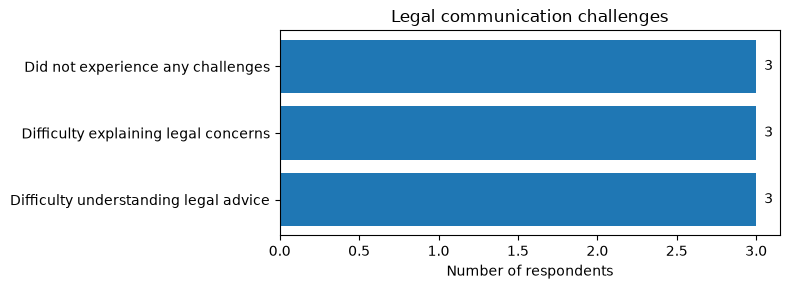

In [ ]:
legal_variables = [
    ("Language barriers made legal services difficult to access", "legal_barrier"),
    ("Interpreter availability for legal services", "legal_interpreter_availability"),
    ("Comfort raising sensitive legal matters through an interpreter", "legal_sensitive_comfort"),
    ("Communication satisfaction during legal services", "legal_communication_satisfaction"),
]

# Display legal-protection response patterns and challenge selections.
for title, field in legal_variables:
    display(Markdown(f"### {title}"))
    markdown_table(frequency([record[field] for record in cleaned]))

legal_challenge_map = {
    "Which_communication_challenges_001/difficulty_explaining_my_legal_concerns": "Difficulty explaining legal concerns",
    "Which_communication_challenges_001/difficulty_understanding_legal_advice": "Difficulty understanding legal advice",
    "Which_communication_challenges_001/difficulty_understanding_legal_procedure": "Difficulty understanding legal procedures",
    "Which_communication_challenges_001/interpreter_not_available": "Interpreter not available",
    "Which_communication_challenges_001/fear_of_misunderstanding_important_infor": "Fear of misunderstanding important information",
    "Which_communication_challenges_001/i_did_not_experience_any_challenges": "Did not experience any challenges",
    "Which_communication_challenges_001/other": "Other",
}
legal_challenge_summary = multiselect_counts(xml_rows, legal_challenge_map)
display(Markdown("### Legal communication challenges"))
markdown_table(legal_challenge_summary)
plot_frequency(legal_challenge_summary, "Legal communication challenges")

### Legal agreement statements

In [ ]:
legal_statement_map = {
    "Interpreter services improve access to legal protection": "group_kr8jw64_row_3_column",
    "I am able to communicate effectively with legal protection services": "group_kr8jw64_row_column",
    "I understand the legal information provided to me": "group_kr8jw64_row_2_column",
    "Language barriers affect my ability to obtain legal protection services": "group_kr8jw64_row_1_column",
}

# Display agreement-statement responses for legal protection topics.
for statement, key in legal_statement_map.items():
    display(Markdown(f"**{statement}**"))
    values = [map_value(row.get(key), agreement_map) for row in xml_rows]
    markdown_table(frequency(values))

**Interpreter services improve access to legal protection**

| Response | Count | Percent |
| --- | --- | --- |
| Strongly agree | 4 | 57.1 |
| Neutral | 2 | 28.6 |
| Agree | 1 | 14.3 |

**I am able to communicate effectively with legal protection services**

| Response | Count | Percent |
| --- | --- | --- |
| Strongly agree | 4 | 57.1 |
| Agree | 2 | 28.6 |
| Disagree | 1 | 14.3 |

**I understand the legal information provided to me**

| Response | Count | Percent |
| --- | --- | --- |
| Strongly agree | 4 | 57.1 |
| Agree | 2 | 28.6 |
| Disagree | 1 | 14.3 |

**Language barriers affect my ability to obtain legal protection services**

| Response | Count | Percent |
| --- | --- | --- |
| Agree | 4 | 57.1 |
| Disagree | 1 | 14.3 |
| Strongly disagree | 1 | 14.3 |
| Strongly agree | 1 | 14.3 |

## 10. Communication strategies and digital tools

### Strategies used when a language barrier occurred

| Response | Count | Percent |
| --- | --- | --- |
| Family or community member interpreting | 4 | 57.1 |
| Gestures or body language | 2 | 28.6 |
| None available | 2 | 28.6 |
| Bilingual staff | 1 | 14.3 |

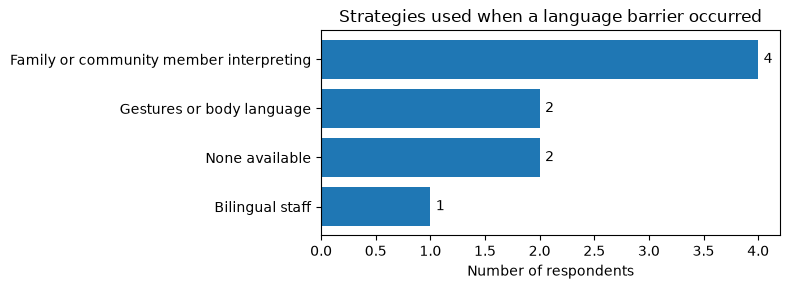

### Barriers to using a phone or translation app

| Response | Count | Percent |
| --- | --- | --- |
| Not applicable / no barrier | 4 | 57.1 |
| No or limited network connectivity | 3 | 42.9 |
| Do not own a phone | 2 | 28.6 |
| Do not know how to use translation apps | 1 | 14.3 |

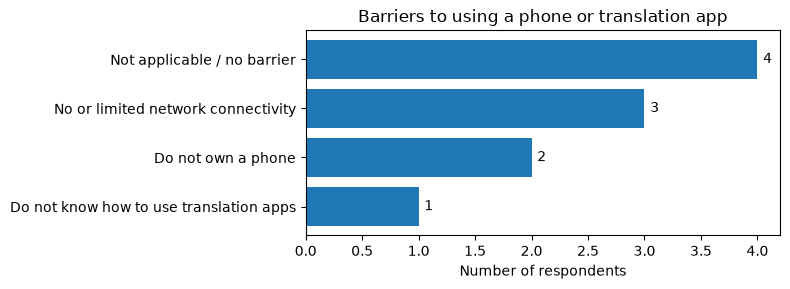

In [ ]:
strategy_map = {
    "Which_of_the_followi_rri_re_linguistique_/family_community_member_interpreting": "Family or community member interpreting",
    "Which_of_the_followi_rri_re_linguistique_/bilingual_staff_at_the_facility": "Bilingual staff",
    "Which_of_the_followi_rri_re_linguistique_/translation_app_on_my_phone": "Translation app",
    "Which_of_the_followi_rri_re_linguistique_/printed_materials_in_my_language": "Printed materials in respondent language",
    "Which_of_the_followi_rri_re_linguistique_/gestures_body_language": "Gestures or body language",
    "Which_of_the_followi_rri_re_linguistique_/none_available": "None available",
}
strategy_summary = multiselect_counts(xml_rows, strategy_map)
display(Markdown("### Strategies used when a language barrier occurred"))
markdown_table(strategy_summary)
plot_frequency(strategy_summary, "Strategies used when a language barrier occurred")

digital_barrier_map = {
    "What_stops_you_from_on_pour_communiquer_/i_don_t_own_a_phone": "Do not own a phone",
    "What_stops_you_from_on_pour_communiquer_/no_limited_network_connectivity": "No or limited network connectivity",
    "What_stops_you_from_on_pour_communiquer_/i_don_t_know_how_to_use_translation_apps": "Do not know how to use translation apps",
    "What_stops_you_from_on_pour_communiquer_/the_app_doesn_t_support_my_language": "App does not support respondent language",
    "What_stops_you_from_on_pour_communiquer_/not_applicable__i_don_t_face_this_barrie": "Not applicable / no barrier",
}
digital_barrier_summary = multiselect_counts(xml_rows, digital_barrier_map)
display(Markdown("### Barriers to using a phone or translation app"))
markdown_table(digital_barrier_summary)
plot_frequency(digital_barrier_summary, "Barriers to using a phone or translation app")

In [ ]:
digital_variables = [
    ("Phone access", "phone_access"),
    ("Mobile internet or Wi-Fi access", "internet_access"),
    ("Reading comfort", "reading_comfort"),
    ("Previous translation-app use", "used_translation_app"),
    ("Likelihood of using a free phone-based tool", "likelihood_use_free_tool"),
    ("Trust in machine translation", "machine_translation_trust"),
    ("Easiest tool format", "preferred_tool_format"),
    ("Preferred interpretation support", "preferred_interpretation_support"),
    ("Main concern when someone interprets", "main_interpretation_concern"),
    ("Comfort with voice recording for translation", "comfortable_voice_recording"),
    ("Overall support for overcoming language barriers", "overall_language_support"),
]

# Display digital tool access and preference responses.
for title, field in digital_variables:
    display(Markdown(f"### {title}"))
    markdown_table(frequency([record[field] for record in cleaned]))

### Phone access

| Response | Count | Percent |
| --- | --- | --- |
| Smartphone with internet access | 7 | 100.0 |

### Mobile internet or Wi-Fi access

| Response | Count | Percent |
| --- | --- | --- |
| Daily | 4 | 57.1 |
| A few times a week | 3 | 42.9 |

### Reading comfort

...

| Response | Count | Percent |
| --- | --- | --- |
| Incorrect translation | 4 | 57.1 |
| Disclosure of private information | 2 | 28.6 |
| Embarrassment | 1 | 14.3 |

### Comfort with voice recording for translation

| Response | Count | Percent |
| --- | --- | --- |
| Yes | 5 | 71.4 |
| Not sure | 1 | 14.3 |
| No | 1 | 14.3 |

### Overall support for overcoming language barriers

| Response | Count | Percent |
| --- | --- | --- |
| Fair/Average | 4 | 57.1 |
| Good | 1 | 14.3 |
| Excellent | 1 | 14.3 |
| Very poor | 1 | 14.3 |

## 11. Ranked improvements

| Priority | Mentions | First choices | Weighted score |
| --- | --- | --- | --- |
| More interpreters available | 6 | 4 | 16 |
| Translated written materials | 5 | 2 | 11 |
| Staff who speak respondent language | 6 | 1 | 9 |
| More time during appointments | 2 | 0 | 3 |
| Other | 1 | 0 | 2 |
| Translation apps or technology | 1 | 0 | 1 |

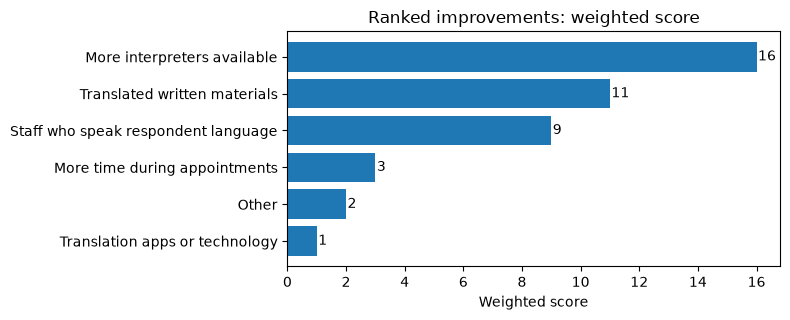

In [ ]:
priority_map = {
    "more_interpreters_available": "More interpreters available",
    "translated_written_materials": "Translated written materials",
    "staff_who_speak_my_language": "Staff who speak respondent language",
    "more_time_during_appointments": "More time during appointments",
    "translation_apps_technology": "Translation apps or technology",
    "other": "Other",
}

priority_rows = []
weights = {
    "_1st_choice_Chaguo_la_1_1er_choix": 3,
    "_2nd_choice_Chaguo_la_2_2e_choix": 2,
    "_3rd_choice_Chaguo_la_3_3e_choix": 1,
}

for row in xml_rows:
    for key, weight in weights.items():
        value = row.get(key)
        if value:
            priority_rows.append({
                "Priority": map_value(value, priority_map),
                "Weight": weight,
                "Rank": {3: "First", 2: "Second", 1: "Third"}[weight],
            })

priority_names = sorted(set(item["Priority"] for item in priority_rows))
priority_summary = []
for name in priority_names:
    matches = [item for item in priority_rows if item["Priority"] == name]
    priority_summary.append({
        "Priority": name,
        "Mentions": len(matches),
        "First choices": sum(1 for item in matches if item["Rank"] == "First"),
        "Weighted score": sum(item["Weight"] for item in matches),
    })
priority_summary.sort(key=lambda x: (-x["Weighted score"], -x["First choices"], x["Priority"]))

# Show rank-weighted improvement priorities and plot the weighted score.
markdown_table(priority_summary)

plt.figure(figsize=(8, max(3, len(priority_summary) * 0.55)))
names = [row["Priority"] for row in priority_summary][::-1]
scores = [row["Weighted score"] for row in priority_summary][::-1]
bars = plt.barh(names, scores)
plt.title("Ranked improvements: weighted score")
plt.xlabel("Weighted score")
for bar, value in zip(bars, scores):
    plt.text(value + 0.05, bar.get_y() + bar.get_height() / 2, str(value), va="center")
plt.tight_layout()
plt.show()

## 12. Preliminary findings

In [ ]:
n = len(cleaned)

general_difficulty = sum(1 for row in cleaned if row["experienced_communication_difficulty"] == "Yes")
health_barrier = sum(1 for row in cleaned if row["healthcare_barrier"] == "Yes")
legal_barrier = sum(1 for row in cleaned if row["legal_barrier"] == "Yes")
left_without_help = sum(1 for row in cleaned if row["left_without_help"] == "Yes")
health_risk = sum(1 for row in cleaned if row["health_put_at_risk"] == "Yes")
app_success = sum(1 for row in cleaned if row["used_translation_app"] == "Yes, and it worked well")
likely_tool = sum(1 for row in cleaned if row["likelihood_use_free_tool"] in ("Somewhat likely", "Very likely"))
voice_format = sum(1 for row in cleaned if row["preferred_tool_format"] == "Voice call with no reading required")
professional_preference = sum(1 for row in cleaned if row["preferred_interpretation_support"] == "Professional interpreter")
inaccurate_concern = sum(1 for row in cleaned if row["main_interpretation_concern"] == "Incorrect translation")

# Build a short exploratory findings summary from the cleaned dataset.
findings = f"""
### Exploratory interpretation

- The dataset contains **{n} eligible adult respondents**, all from a single form version.
- **4 out of 7** respondents lived in Kakuma, **2 out of 7** were in another refugee-hosting area in Kenya, and **1 out of 7** was in Bidibidi, Uganda.
- **6 out of 7** respondents were from the Democratic Republic of the Congo, and **1 out of 7** was from Burundi.
- **{general_difficulty} out of {n}** reported having experienced communication difficulties when accessing healthcare or legal protection services.
- **{health_barrier} out of {n}** said language barriers had made healthcare access challenging, while **{legal_barrier} out of {n}** said the same for legal services.
- **{left_without_help} out of {n}** had left a health or legal service without receiving help because of a language barrier.
- **{health_risk} out of {n}** felt that a language barrier had put their health at risk.
- **{app_success} out of {n}** had used a translation app with a service provider and reported that it worked well.
- **{likely_tool} out of {n}** were somewhat or very likely to use a free phone-based translation tool.
- A **voice call requiring no reading** was preferred by **{voice_format} out of {n}** respondents.
- A **professional interpreter** was the most common preferred source of interpretation support, selected by **{professional_preference} out of {n}**.
- **Incorrect translation** was the most common concern about interpretation, selected by **{inaccurate_concern} out of {n}** respondents.
- The highest weighted improvement priority was **{priority_summary[0]["Priority"]}**.

These findings are preliminary and cannot be generalised beyond the seven respondents.
"""
display(Markdown(findings))


### Exploratory interpretation

- The dataset contains **7 eligible adult respondents**, all from a single form version.
- **4 out of 7** respondents lived in Kakuma, **2 out of 7** were in another refugee-hosting area in Kenya, and **1 out of 7** was in Bidibidi, Uganda.
- **6 out of 7** respondents were from the Democratic Republic of the Congo, and **1 out of 7** was from Burundi.
- **4 out of 7** reported having experienced communication difficulties when accessing healthcare or legal protection services.
- **3 out of 7** said language barriers had made healthcare access challenging, while **3 out of 7** said the same for legal services.
- **2 out of 7** had left a health or legal service without receiving help because of a language barrier.
- **4 out of 7** felt that a language barrier had put their health at risk.
- **4 out of 7** had used a translation app with a service provider and reported that it worked well.
- **5 out of 7** were somewhat or very likely to use a free phone-based translation tool.
- A **voice call requiring no reading** was preferred by **5 out of 7** respondents.
- A **professional interpreter** was the most common preferred source of interpretation support, selected by **3 out of 7**.
- **Incorrect translation** was the most common concern about interpretation, selected by **4 out of 7** respondents.
- The highest weighted improvement priority was **More interpreters available**.

These findings are preliminary and cannot be generalised beyond the seven respondents.


## 13. Limitations and reporting cautions

1. **Very small convenience sample:** seven respondents are insufficient for population-level conclusions or statistical testing.
2. **Geographic concentration:** most respondents were in Kenya, especially Kakuma; only one respondent was in Bidibidi.
3. **Gender imbalance:** six of seven respondents were male.
4. **Missing screening data:** formal status and prior use of health/legal services were blank for all respondents.
5. **Logical inconsistencies:** some respondents selected communication challenges after reporting no communication difficulty; two reported smartphone access but also selected that they did not own a phone; two selected both a legal challenge and “no legal challenges.”
6. **Questionnaire coding issue:** in the healthcare challenge item, the XML value `other` corresponds to the label “I did not experience any challenges.” The notebook uses the displayed label rather than the misleading technical code.
7. **All conditional sections were completed:** healthcare and legal questions contain responses for all seven people, even though direct service-use screening fields are blank. Sector-specific findings therefore require cautious interpretation.
8. **Multilingual free text:** mother-tongue responses were entered as free text and should be reported as provided rather than over-standardised.


## 14. Export cleaned data and summary tables

In [ ]:
# Ensure the output folder exists before exporting summary CSV files.
OUTPUT_DIR = DATA_DIR / "refugee_analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
write_csv(OUTPUT_DIR / "refugee_survey_cleaned.csv", cleaned)
write_csv(OUTPUT_DIR / "communication_challenges_summary.csv", general_challenge_summary)
write_csv(OUTPUT_DIR / "healthcare_challenges_summary.csv", health_challenge_summary)
write_csv(OUTPUT_DIR / "legal_challenges_summary.csv", legal_challenge_summary)
write_csv(OUTPUT_DIR / "communication_strategies_summary.csv", strategy_summary)
write_csv(OUTPUT_DIR / "digital_barriers_summary.csv", digital_barrier_summary)
write_csv(OUTPUT_DIR / "priority_summary.csv", priority_summary)
write_csv(OUTPUT_DIR / "data_quality_contradictions.csv", contradictions)

# List the generated CSV outputs after saving.
print("Files saved to:", OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path.name)

Files saved to: data\refugee_analysis_outputs
- communication_challenges_summary.csv
- communication_strategies_summary.csv
- data_quality_contradictions.csv
- digital_barriers_summary.csv
- healthcare_challenges_summary.csv
- legal_challenges_summary.csv
- priority_summary.csv
- refugee_survey_cleaned.csv


## 15. Next step

After validating these findings, the refugee results can be integrated with the service-provider results in the final report. The two datasets should remain analytically separate, with a later comparison section identifying where provider and refugee perspectives converge or differ.
